## Data Analysis

3/7/2021

Clelia Corridori


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

import pandas as pd
import scipy.integrate as spi

In [2]:
# exponential function to fit
def func_exp(x, m, t, b):
    return m * np.exp(x*t) + b


In [3]:
# time
time =np.array([6, 18, 24, 48])
time_grid = np.linspace(0,48,49) #each step is an hour

In [4]:
# Cells counts
S3_plus1  = np.array([1.51, 3.83, 5.14, 24.4])*10**5/2
S3_plus2  = np.array([1.38, 4.13, 5.01, 22.3])*10**5/2
S3_plus3  = np.array([1.23, 3.73, 5.70, 26.9])*10**5/2

S3_minus1 = np.array([1.19, 2.70, 4.63, 11.2])*10**5/2
S3_minus2 = np.array([1.41, 3.22, 4.40, 12.3])*10**5/2
S3_minus3 = np.array([1.36, 3.18, 3.80, 12.7])*10**5/2

In [5]:
Matx_S3_plus = np.reshape(np.concatenate((S3_plus1, S3_plus2, S3_plus3), axis=0), (3,4))
Matx_S3_minus = np.reshape(np.concatenate((S3_minus1, S3_minus2, S3_minus3), axis=0), (3,4))

print(Matx_S3_plus)
print(Matx_S3_minus)

[[  75500.  191500.  257000. 1220000.]
 [  69000.  206500.  250500. 1115000.]
 [  61500.  186500.  285000. 1345000.]]
[[ 59500. 135000. 231500. 560000.]
 [ 70500. 161000. 220000. 615000.]
 [ 68000. 159000. 190000. 635000.]]


In [6]:
Mean_S3plus= np.mean(Matx_S3_plus, axis=0)
Mean_S3minus= np.mean(Matx_S3_minus, axis=0)
print(Mean_S3plus)
print(Mean_S3minus)

Std_S3plus= np.std(Matx_S3_plus, axis=0)
Std_S3minus= np.std(Matx_S3_minus, axis=0)
print(Std_S3plus)
print(Std_S3minus)

[  68666.66666667  194833.33333333  264166.66666667 1226666.66666667]
[ 66000.         151666.66666667 213833.33333333 603333.33333333]
[ 5720.33410058  8498.36585599 14968.48541288 94015.36517447]
[ 4708.14896394 11813.36343111 17494.44356233 31710.49598407]


Text(0, 0.5, 'Cells Counts')

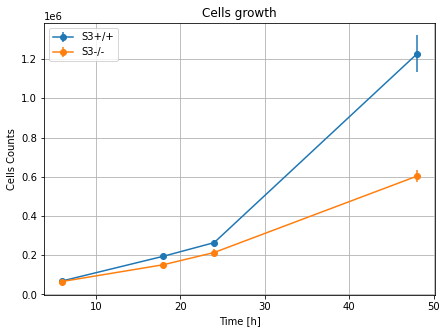

In [7]:
plt.figure(figsize=(7,5))
plt.errorbar(time, Mean_S3plus[:], Std_S3plus[:], fmt='-o',   label="S3+/+")
plt.errorbar(time, Mean_S3minus[:], Std_S3minus[:], fmt='-o', label="S3-/-")
plt.legend()
plt.grid()
plt.title("Cells growth")
plt.xlabel("Time [h]")
plt.ylabel("Cells Counts")

Params cells [ 1.47468705e+05  3.29615266e-02 -1.13787876e+05]
Std params cells [1.01556403e+04 1.18199152e-03 1.14449116e+04]


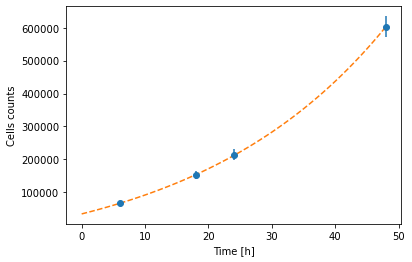

In [8]:
p0 = (6.37117879e+04, 7.47914082e-02, 1.44824216e+05)
params_minus, var_cells_minus = scipy.optimize.curve_fit(func_exp, time, Mean_S3minus, p0, Std_S3minus)
m_minus, t_minus, b_minus = params_minus

std_params_cells_minus = np.sqrt(np.diag(var_cells_minus))
print("Params cells", params_minus)
print("Std params cells", std_params_cells_minus)

fitted_cells_minus = func_exp(time_grid, m_minus, t_minus, b_minus)

plt.errorbar(time, Mean_S3minus, Std_S3minus, fmt='o')
plt.plot(time_grid, fitted_cells_minus, '--', label="fitted")
# plt.yscale("log")
plt.xlabel("Time [h]")
plt.ylabel("Cells counts")


integrand_minus = lambda x : m_minus * np.exp(x*t_minus) + b_minus

Dtime = time[1:]-time[:-1]
tstep = np.linspace(0,2,3)

# result, error = [spi.quad(integrand, time[i], time[i+1]) for i in range(0,3)]
result1, error1 = spi.quad(integrand_minus, time[0], time[1])
result2, error2 = spi.quad(integrand_minus, time[1], time[2])
result3, error3 = spi.quad(integrand_minus, time[2], time[3]) 

areas_minus = np.array([result1, result2, result3])
Std_areas_minus = np.array([error1, error2, error3])

# print(areas_minus, Std_areas_minus)

Params cells [ 8.94901075e+04  5.50899334e-02 -5.45731282e+04]
Std params cells [2.88675931e+04 7.80961453e-03 3.93132932e+04]


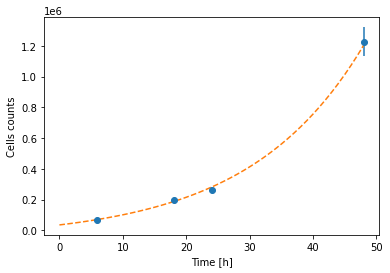

In [9]:
p0 = (6.37117879e+04, 7.47914082e-02, 1.44824216e+05)
params_plus, var_cells_plus = scipy.optimize.curve_fit(func_exp, time, Mean_S3plus, p0, Std_S3plus)
m_plus, t_plus, b_plus = params_plus

std_params_cells_plus = np.sqrt(np.diag(var_cells_plus))
print("Params cells", params_plus)
print("Std params cells", std_params_cells_plus)

fitted_cells_plus = func_exp(time_grid, m_plus, t_plus, b_plus)

plt.errorbar(time, Mean_S3plus, Std_S3plus, fmt='o')
plt.plot(time_grid, fitted_cells_plus, '--', label="fitted")
# plt.yscale("log")
plt.xlabel("Time [h]")
plt.ylabel("Cells counts")



integrand_plus = lambda x : m_plus * np.exp(x*t_plus) + b_plus

Dtime = time[1:]-time[:-1]
tstep = np.linspace(0,2,3)

# result, error = [spi.quad(integrand, time[i], time[i+1]) for i in range(0,3)]
result1, error1 = spi.quad(integrand_plus, time[0], time[1])
result2, error2 = spi.quad(integrand_plus, time[1], time[2])
result3, error3 = spi.quad(integrand_plus, time[2], time[3]) 

areas_plus = np.array([result1, result2, result3])
Std_areas_plus = np.array([error1, error2, error3])

# print(areas_plus, Std_areas_plus)

# Glucose

Text(0, 0.5, 'Glucose Concentration')

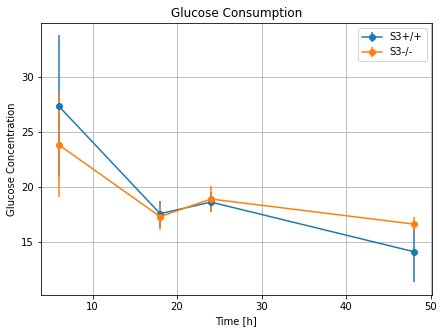

In [10]:
# df = pd.read_excel(r'Metaboliti.xlsx')
# print(df)

Mean_glucose_S3plus  = np.array([ 27.37, 17.54, 18.60, 14.07])
Mean_glucose_S3minus = np.array([ 23.84, 17.27, 18.88, 16.59])

Std_glucose_S3plus  = np.array([ 6.46, 1.17, 0.91, 2.81])
Std_glucose_S3minus = np.array([ 4.76, 1.18, 1.20, 0.63])

plt.figure(figsize=(7,5))
plt.errorbar(time, Mean_glucose_S3plus[:], Std_glucose_S3plus[:], fmt='-o',   label="S3+/+")
plt.errorbar(time, Mean_glucose_S3minus[:], Std_glucose_S3minus[:], fmt='-o', label="S3-/-")
plt.legend()
plt.grid()
plt.title("Glucose Consumption")
plt.xlabel("Time [h]")
plt.ylabel("Glucose Concentration")

In [11]:
def incert(x1, x2, x3, dx1, dx2, dx3):
    df = (1/x3)*np.sqrt(dx2**2+dx1**2+(dx3**2/x3**2)*(x1-x2)**2)
    return(df)

Text(0, 0.5, 'Glucose variation')

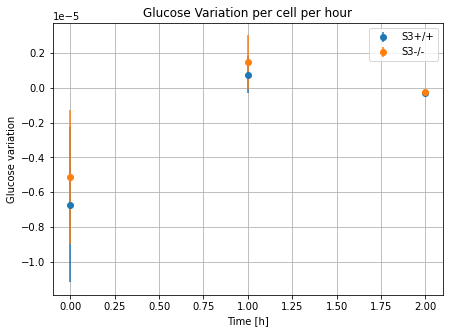

In [12]:
#Glucose Differences

# +/+
diff_Plus_data = (Mean_glucose_S3plus[1:]-Mean_glucose_S3plus[:-1])/areas_plus
Std_diff_Plus_prop =[incert(Mean_glucose_S3plus[i+1], Mean_glucose_S3plus[i], areas_plus[i], Std_glucose_S3plus[i+1], Std_glucose_S3plus[i], Std_areas_plus[i]) for i in range(0,3)]

# -/-
diff_Minus_data = (Mean_glucose_S3minus[1:]-Mean_glucose_S3minus[:-1])/areas_minus
Std_diff_Minus_prop =[incert(Mean_glucose_S3minus[i+1], Mean_glucose_S3minus[i], areas_minus[i], Std_glucose_S3minus[i+1], Std_glucose_S3minus[i], Std_areas_minus[i]) for i in range(0,3)]

plt.figure(figsize=(7,5))
plt.errorbar(tstep, diff_Plus_data, Std_diff_Plus_prop, fmt='o',   label="S3+/+")
plt.errorbar(tstep, diff_Minus_data, Std_diff_Minus_prop, fmt='o',   label="S3-/-")
plt.legend()
plt.grid()
plt.title("Glucose Variation per cell per hour")
plt.xlabel("Time [h]")
plt.ylabel("Glucose variation")

# Std_diff_Plus_data = np.sqrt(Std_glucose_S3plus[1:]**2+Std_glucose_S3plus[:-1]**2)/Dtime
# Std_diff_Plus_tc = np.sqrt(Std_diff_Plus_data**2/Mean_S3plus[:-1]**2 + (diff_Plus_data*Std_S3plus[:-1])**2/Mean_S3plus[:-1]**4)


Glucose Variation per cell per hour for +/+:
 [-6.72e-06  7.60e-07 -2.90e-07] 
 [4.49e-06 1.07e-06 1.90e-07]
Glucose Variation per cell per hour for -/-:
 [-5.13e-06  1.48e-06 -2.50e-07] 
 [3.83e-06 1.55e-06 1.50e-07]


Text(0, 0.5, 'Glucose variation')

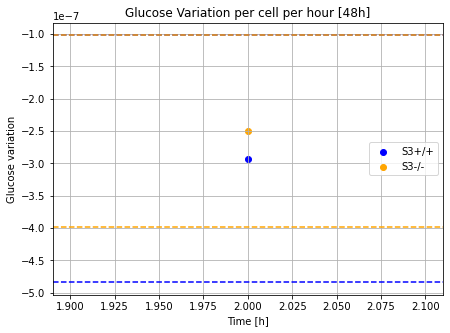

In [13]:
print("Glucose Variation per cell per hour for +/+:\n", np.round(diff_Plus_data,8), "\n", np.round(Std_diff_Plus_prop, 8))
print("Glucose Variation per cell per hour for -/-:\n", np.round(diff_Minus_data,8), "\n", np.round(Std_diff_Minus_prop, 8))

plt.figure(figsize=(7,5))
plt.scatter(tstep[-1], diff_Plus_data[-1], color='blue',   label="S3+/+")
plt.scatter(tstep[-1], diff_Minus_data[-1], color='orange',   label="S3-/-")

plt.axhline(y = diff_Plus_data[-1]+ Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')
plt.axhline(y = diff_Plus_data[-1]- Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')

plt.axhline(y = diff_Minus_data[-1]+ Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')
plt.axhline(y = diff_Minus_data[-1]- Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')

plt.legend()
plt.grid()
plt.title("Glucose Variation per cell per hour [48h]")
plt.xlabel("Time [h]")
plt.ylabel("Glucose variation")

# Lactate

Text(0, 0.5, 'Lactate Concentration')

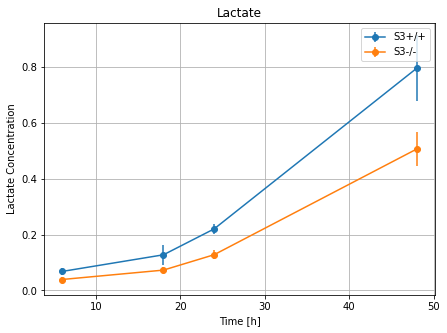

In [14]:
time =np.array([6, 18, 24, 48])

# Mean_lact_S3plus  = np.array([-0.05263,-0.00292, 0.05664, 0.14922, 0.72444])
# Mean_lact_S3minus = np.array([-0.05263,-0.03167, 0.00193, 0.05696, 0.43533])
 
# Std_lact_S3plus  = np.array([0, 0.01320, 0.03539, 0.01817, 0.11664])
# Std_lact_S3minus = np.array([0, 0.01048, 0.01120, 0.01557, 0.06032])

Mean_lact_S3plus  = np.array([-0.00292, 0.05664, 0.14922, 0.72444])+0.07082 #blk added
Mean_lact_S3minus = np.array([-0.03167, 0.00193, 0.05696, 0.43533])+0.07082 #blk added
 
Std_lact_S3plus  = np.array([0.01320, 0.03539, 0.01817, 0.11664])
Std_lact_S3minus = np.array([0.01048, 0.01120, 0.01557, 0.06032])

plt.figure(figsize=(7,5))
plt.errorbar(time, Mean_lact_S3plus[:], Std_lact_S3plus[:], fmt='-o',   label="S3+/+")
plt.errorbar(time, Mean_lact_S3minus[:], Std_lact_S3minus[:], fmt='-o', label="S3-/-")
plt.legend()
plt.grid()
plt.title("Lactate")
plt.xlabel("Time [h]")
plt.ylabel("Lactate Concentration")

Text(0, 0.5, 'Lactate variation')

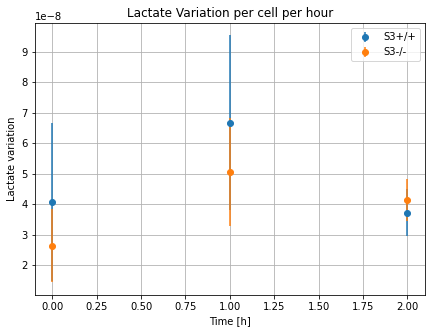

In [15]:
#Lactate Differences
# +/+
lact_diff_Plus_data = (Mean_lact_S3plus[1:]-Mean_lact_S3plus[:-1])/areas_plus
lact_Std_diff_Plus_prop = [incert(Mean_lact_S3plus[i+1], Mean_lact_S3plus[i], areas_plus[i], Std_lact_S3plus[i+1], Std_lact_S3plus[i], Std_areas_plus[i]) for i in range(0,3)]
# lact_Std_diff_Plus_data = np.sqrt(Std_lact_S3plus[1:]**2+Std_lact_S3plus[:-1]**2)
# lact_Std_diff_Plus_dataN = lact_Std_diff_Plus_data/Mean_S3plus[:-1] + lact_diff_Plus_data*Std_S3plus[:-1]/Mean_S3plus[:-1]**2


# -/-
lact_diff_Minus_data = (Mean_lact_S3minus[1:]-Mean_lact_S3minus[:-1])/areas_minus
lact_Std_diff_Minus_prop = [incert(Mean_lact_S3minus[i+1], Mean_lact_S3minus[i], areas_minus[i], Std_lact_S3minus[i+1], Std_lact_S3minus[i], Std_areas_minus[i]) for i in range(0,3)]
# lact_Std_diff_Minus_data = np.sqrt(Std_lact_S3minus[1:]**2+Std_lact_S3minus[:-1]**2)
# lact_Std_diff_Minus_dataN = lact_Std_diff_Minus_data/Mean_S3minus[:-1] + lact_diff_Minus_data*Std_S3minus[:-1]/Mean_S3minus[:-1]**2


plt.figure(figsize=(7,5))
plt.errorbar(tstep, lact_diff_Plus_data[:], lact_Std_diff_Plus_prop[:], fmt='o',   label="S3+/+")
plt.errorbar(tstep, lact_diff_Minus_data[:], lact_Std_diff_Minus_prop[:], fmt='o',   label="S3-/-")

plt.legend()
plt.grid()
plt.title("Lactate variation per cell per hour")
plt.xlabel("Time [h]")
plt.ylabel("Lactate variation")


Lactate Variation per cell per hour for +/+:
 [4.07e-08 6.67e-08 3.72e-08] 
 [2.58e-08 2.87e-08 7.60e-09]
Lactate Variation per cell per hour for -/-:
 [2.63e-08 5.06e-08 4.13e-08] 
 [1.20e-08 1.76e-08 6.80e-09]


Text(0, 0.5, 'Lactate variation')

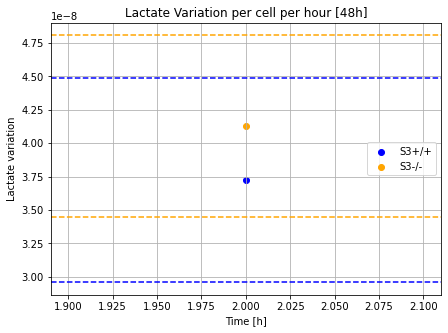

In [16]:
print("Lactate Variation per cell per hour for +/+:\n", np.round(lact_diff_Plus_data,10), "\n",  np.round(lact_Std_diff_Plus_prop, 10))
print("Lactate Variation per cell per hour for -/-:\n", np.round(lact_diff_Minus_data,10), "\n", np.round(lact_Std_diff_Minus_prop, 10))

plt.figure(figsize=(7,5))
plt.scatter(tstep[-1], lact_diff_Plus_data[-1], color='blue',   label="S3+/+")
plt.scatter(tstep[-1], lact_diff_Minus_data[-1], color='orange',   label="S3-/-")

plt.axhline(y = lact_diff_Plus_data[-1]+  lact_Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')
plt.axhline(y = lact_diff_Plus_data[-1]-  lact_Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')

plt.axhline(y = lact_diff_Minus_data[-1]+ lact_Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')
plt.axhline(y = lact_diff_Minus_data[-1]- lact_Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')

plt.legend()
plt.grid()
plt.title("Lactate variation per cell per hour [48h]")
plt.xlabel("Time [h]")
plt.ylabel("Lactate variation")

# Glutamine

Text(0, 0.5, 'Glutamine Concentration')

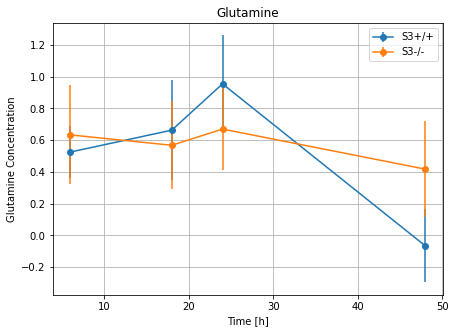

In [17]:
time =np.array([6, 18, 24, 48])

# Mean_gln_S3plus  = np.array([1.88045, 1.84343, 1.98143, 2.27297, 1.25218])
# Mean_gln_S3minus = np.array([1.88000, 1.95150, 1.88620, 1.98814, 1.73572])
 
#  Std_gln_S3plus  = np.array([0, 0.16131, 0.31424, 0.30550, 0.22995])
#  Std_gln_S3minus = np.array([0, 0.31188, 0.27755, 0.25644, 0.30082])

Mean_gln_S3plus  = np.array([1.84343, 1.98143, 2.27297, 1.25218])-1.31854
Mean_gln_S3minus = np.array([1.95150, 1.88620, 1.98814, 1.73572])-1.31854
 
Std_gln_S3plus  = np.array([0.16131, 0.31424, 0.30550, 0.22995])
Std_gln_S3minus = np.array([0.31188, 0.27755, 0.25644, 0.30082])

plt.figure(figsize=(7,5))
plt.errorbar(time, Mean_gln_S3plus[:],  Std_gln_S3plus[:], fmt='-o',   label="S3+/+")
plt.errorbar(time, Mean_gln_S3minus[:], Std_gln_S3minus[:], fmt='-o', label="S3-/-")
plt.legend()
plt.grid()
plt.title("Glutamine")
plt.xlabel("Time [h]")
plt.ylabel("Glutamine Concentration")

Text(0, 0.5, 'Glutamine variation')

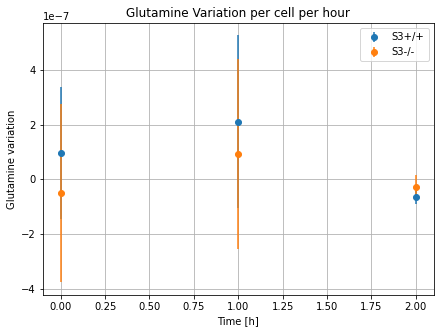

In [18]:
# Glutamine Differences
# +/+
gln_diff_Plus_data = (Mean_gln_S3plus[1:]-Mean_gln_S3plus[:-1])/areas_plus
gln_Std_diff_Plus_prop = [incert(Mean_gln_S3plus[i+1], Mean_gln_S3plus[i], areas_plus[i], Std_gln_S3plus[i+1], Std_gln_S3plus[i], Std_areas_plus[i]) for i in range(0,3)]

# -/-
gln_diff_Minus_data = (Mean_gln_S3minus[1:]-Mean_gln_S3minus[:-1])/areas_minus
gln_Std_diff_Minus_prop = [incert(Mean_gln_S3minus[i+1], Mean_gln_S3minus[i], areas_minus[i], Std_gln_S3minus[i+1], Std_gln_S3minus[i], Std_areas_minus[i]) for i in range(0,3)]

plt.figure(figsize=(7,5))
plt.errorbar(tstep, gln_diff_Plus_data,  gln_Std_diff_Plus_prop, fmt='o',   label="S3+/+")
plt.errorbar(tstep, gln_diff_Minus_data, gln_Std_diff_Minus_prop, fmt='o',   label="S3-/-")

plt.legend()
plt.grid()
plt.title("Glutamine Variation per cell per hour")
plt.xlabel("Time [h]")
plt.ylabel("Glutamine variation")


Glutamine Variation per cell per hour for +/+:
 [ 9.430e-08  2.101e-07 -6.600e-08] 
 [2.414e-07 3.158e-07 2.470e-08]
Glutamine Variation per cell per hour for -/-:
 [-5.10e-08  9.37e-08 -2.75e-08] 
 [3.262e-07 3.473e-07 4.310e-08]


Text(0, 0.5, 'Glutamine variation')

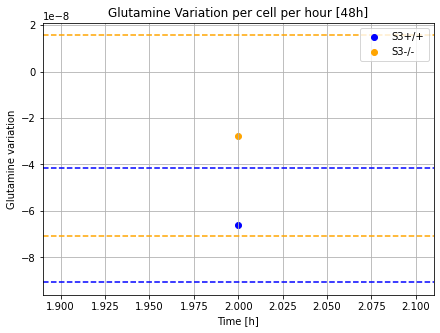

In [23]:
print("Glutamine Variation per cell per hour for +/+:\n", np.round(gln_diff_Plus_data,10), "\n",  np.round(gln_Std_diff_Plus_prop, 10))
print("Glutamine Variation per cell per hour for -/-:\n", np.round(gln_diff_Minus_data,10), "\n", np.round(gln_Std_diff_Minus_prop, 10))

plt.figure(figsize=(7,5))
plt.scatter(tstep[-1], gln_diff_Plus_data[-1], color='blue',   label="S3+/+")
plt.scatter(tstep[-1], gln_diff_Minus_data[-1], color='orange',   label="S3-/-")

plt.axhline(y = gln_diff_Plus_data[-1]+  gln_Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')
plt.axhline(y = gln_diff_Plus_data[-1]-  gln_Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')

plt.axhline(y = gln_diff_Minus_data[-1]+ gln_Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')
plt.axhline(y = gln_diff_Minus_data[-1]- gln_Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')

plt.legend()
plt.grid()
plt.title("Glutamine Variation per cell per hour [48h]")
plt.xlabel("Time [h]")
plt.ylabel("Glutamine variation")

# Glutamate


Text(0, 0.5, 'glutamate Concentration')

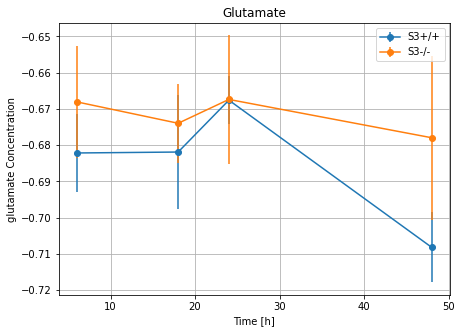

In [20]:
time =np.array([6, 18, 24, 48])

# Mean_glu_S3plus  = np.array([-0.01588, 0.06766, 0.06792, 0.08224, 0.04159])
# Mean_glu_S3minus = np.array([-0.01588, 0.08177, 0.07586, 0.08244, 0.07186])
 
# Std_glu_S3plus  =  np.array([0, 0.01065, 0.01571, 0.00658, 0.00967])
# Std_glu_S3minus =  np.array([0, 0.01542, 0.01091, 0.01769, 0.02259])

Mean_glu_S3plus  = np.array([0.06766, 0.06792, 0.08224, 0.04159])-0.74983
Mean_glu_S3minus = np.array([0.08177, 0.07586, 0.08244, 0.07186])-0.74983
 
Std_glu_S3plus  = np.array([ 0.01065, 0.01571, 0.00658, 0.00967])
Std_glu_S3minus = np.array([ 0.01542, 0.01091, 0.01769, 0.02259])

plt.figure(figsize=(7,5))
plt.errorbar(time, Mean_glu_S3plus[:],  Std_glu_S3plus[:], fmt='-o',   label="S3+/+")
plt.errorbar(time, Mean_glu_S3minus[:], Std_glu_S3minus[:], fmt='-o', label="S3-/-")
plt.legend()
plt.grid()
plt.title("Glutamate")
plt.xlabel("Time [h]")
plt.ylabel("glutamate Concentration")

Text(0, 0.5, 'Glutamate variation')

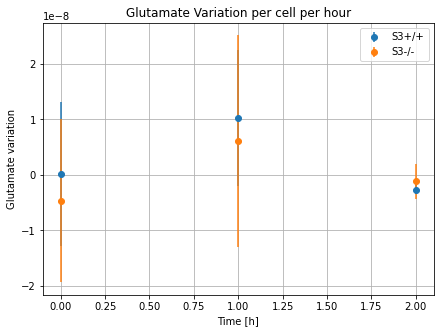

In [21]:
# Glu Differences
# +/+
glu_diff_Plus_data = (Mean_glu_S3plus[1:]-Mean_glu_S3plus[:-1])/areas_plus
glu_Std_diff_Plus_prop = [incert(Mean_glu_S3plus[i+1], Mean_glu_S3plus[i], areas_plus[i], Std_glu_S3plus[i+1], Std_glu_S3plus[i], Std_areas_plus[i]) for i in range(0,3)]

# -/-
glu_diff_Minus_data = (Mean_glu_S3minus[1:]-Mean_glu_S3minus[:-1])/areas_minus
glu_Std_diff_Minus_prop = [incert(Mean_glu_S3minus[i+1], Mean_glu_S3minus[i], areas_minus[i], Std_glu_S3minus[i+1], Std_glu_S3minus[i], Std_areas_minus[i]) for i in range(0,3)]

plt.figure(figsize=(7,5))
plt.errorbar(tstep, glu_diff_Plus_data[:],  glu_Std_diff_Plus_prop, fmt='o',   label="S3+/+")
plt.errorbar(tstep, glu_diff_Minus_data[:], glu_Std_diff_Minus_prop, fmt='o',   label="S3-/-")

plt.legend()
plt.grid()
plt.title("Glutamate Variation per cell per hour")
plt.xlabel("Time [h]")
plt.ylabel("Glutamate variation")


Glutamate Variation per cell per hour for +/+:
 [ 2.00e-10  1.03e-08 -2.60e-09] 
 [1.30e-08 1.23e-08 8.00e-10]
Glutamate Variation per cell per hour for -/-:
 [-4.6e-09  6.0e-09 -1.2e-09] 
 [1.48e-08 1.91e-08 3.10e-09]


Text(0, 0.5, 'Glutamate variation')

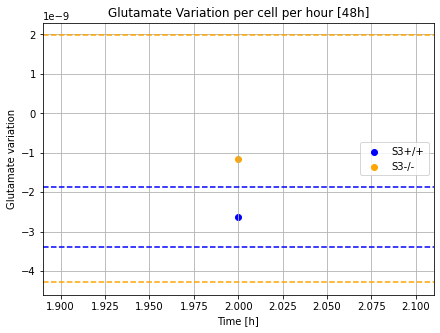

In [24]:
print("Glutamate Variation per cell per hour for +/+:\n", np.round(glu_diff_Plus_data,10), "\n",  np.round(glu_Std_diff_Plus_prop, 10))
print("Glutamate Variation per cell per hour for -/-:\n", np.round(glu_diff_Minus_data,10), "\n", np.round(glu_Std_diff_Minus_prop, 10))

plt.figure(figsize=(7,5))
plt.scatter(tstep[-1], glu_diff_Plus_data[-1], color='blue',   label="S3+/+")
plt.scatter(tstep[-1], glu_diff_Minus_data[-1], color='orange',   label="S3-/-")

plt.axhline(y = glu_diff_Plus_data[-1]+  glu_Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')
plt.axhline(y = glu_diff_Plus_data[-1]-  glu_Std_diff_Plus_prop[-1], color = 'blue', linestyle = '--')

plt.axhline(y = glu_diff_Minus_data[-1]+ glu_Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')
plt.axhline(y = glu_diff_Minus_data[-1]- glu_Std_diff_Minus_prop[-1], color = 'orange', linestyle = '--')

plt.legend()
plt.grid()
plt.title("Glutamate Variation per cell per hour [48h]")
plt.xlabel("Time [h]")
plt.ylabel("Glutamate variation")